# IMPORTAZIONE LIBRERIE

In [1719]:
import pandas as pd
import os
import numpy as np

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
sns.set_theme()

# ANALISI TEMPORALE 

Per descrivere l' evoluzione nel tempo degli incidenti dall' anno 2020 al 2024

In [1720]:
df_incidenti_annuali=pd.read_csv('df_clean/df_incidenti.csv')
df_incidenti_annuali.info()

<class 'pandas.DataFrame'>
RangeIndex: 37933 entries, 0 to 37932
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID_COMUNE                   37933 non-null  int64  
 1   DATA_TYPE                   37933 non-null  str    
 2   RESULTS                     37933 non-null  str    
 3   TIME_PERIOD                 37933 non-null  int64  
 4   OBS_VALUE                   37933 non-null  int64  
 5   CODICE PROVINCIA            37933 non-null  int64  
 6   COMUNE                      37933 non-null  str    
 7   RESIDENTI                   37933 non-null  int64  
 8   SUPERFICIE (KMQ)            37933 non-null  float64
 9   INCIDENTI_PRO_CAPITE(1000)  37933 non-null  float64
 10  DENSITA_INCIDENTI           37933 non-null  float64
 11  DENSITA_POPOLAZIONE         37933 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 3.5 MB


### COME SONO CAMBIATI GLI INCIDENTI NEL TEMPO? ANNO CON PIU' INCIDENTI?

Negli anni presi in considerazione, dunque dal 2020 al 2024 gli incidenti hanno subito un andamento crescente e l' anno con maggiori incidenti è il 2024, nonostante non abbia lo stesso numero di record registrati degli altri dal momento in cui ne ha meno.

Fatta eccezione per il 2020 che rispetto agli altri anni presenta un numero totale di incidenti basso, probabilmente a causa della pandemia di covid-19.

In [1721]:
incidenti_annui = (df_incidenti_annuali.groupby("TIME_PERIOD", as_index=False)["OBS_VALUE"].sum())
incidenti_annui

,TIME_PERIOD,OBS_VALUE
0,2020,118298
1,2021,151862
2,2022,165879
3,2023,166513
4,2024,173316


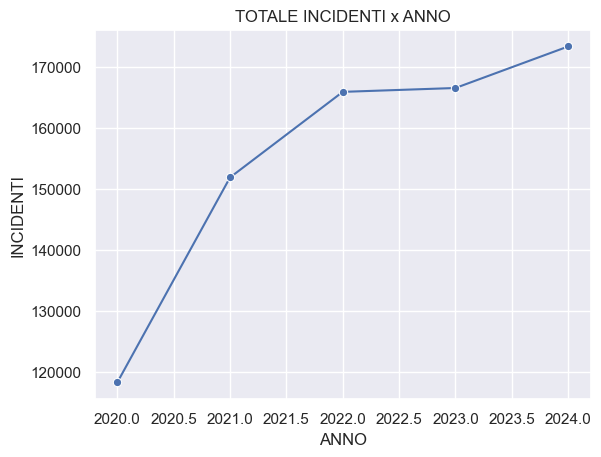

In [1722]:
sns.lineplot(data=incidenti_annui,x="TIME_PERIOD",y="OBS_VALUE",marker="o")

plt.title("TOTALE INCIDENTI x ANNO")
plt.xlabel("ANNO")
plt.ylabel("INCIDENTI")
plt.show()

### COME CAMBIA IL TASSO PRO CAPITE?

In concordanza con i dati, non avendo grandi variazioni il numero dei residenti, l' andamento è pressocchè crescente come quello degli incidenti assoluti.

In [1723]:
#da ricalcolare il pro capite, in maniera tale che sia sull' anno e non la somma dei pro capite precedenti
pro_capite_annuo = (df_incidenti_annuali.groupby("TIME_PERIOD", as_index=False).agg({"OBS_VALUE": "sum","RESIDENTI": "sum"}))

pro_capite_annuo["INCIDENTI_PRO_CAPITE(1000)"] = (pro_capite_annuo["OBS_VALUE"]/pro_capite_annuo["RESIDENTI"]) * 1000

pro_capite_annuo

,TIME_PERIOD,OBS_VALUE,RESIDENTI,INCIDENTI_PRO_CAPITE(1000)
0,2020,118298,59236213,1.997055
1,2021,151862,59233797,2.563773
2,2022,165879,59233797,2.800411
3,2023,166513,59229754,2.811307
4,2024,173316,57881979,2.994300


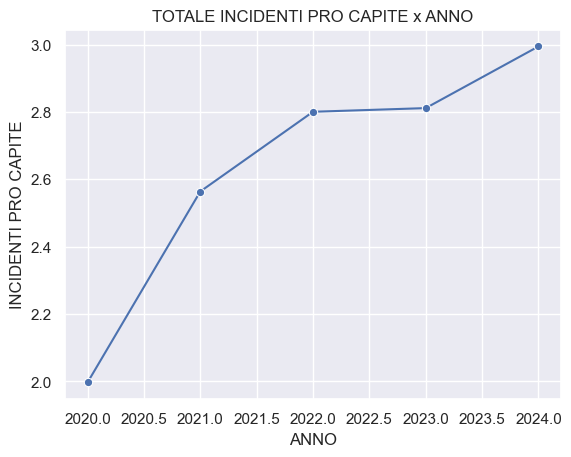

In [1724]:
sns.lineplot(data=pro_capite_annuo,x="TIME_PERIOD",y="INCIDENTI_PRO_CAPITE(1000)",marker="o")

plt.title("TOTALE INCIDENTI PRO CAPITE x ANNO")
plt.xlabel("ANNO")
plt.ylabel("INCIDENTI PRO CAPITE")
plt.show()

### COME CAMBIA LA DENSITA' DEGLI INCIDENTI?

La densità di incidenti è aumentata negli anni con una maggiorazione da evidenziare nell' intervallo degli aa 2020-2021 (nel 2020 c' è stata la pandemia di covid-19 = meno persone si 
mobilitavano per le strade) e 2023-2024.

https://www.istat.it/comunicato-stampa/incidenti-stradali-in-italia-anno-2020/

In [1725]:
#da ricalcolare la densità annua di incidenti, in maniera tale che sia sull' anno e non la somma delle densità precedenti
densita_annua_nazionale = (df_incidenti_annuali.groupby("TIME_PERIOD", as_index=False).agg({"OBS_VALUE": "sum","SUPERFICIE (KMQ)": "sum"}))

densita_annua_nazionale["DENSITA_INCIDENTI"] = (densita_annua_nazionale["OBS_VALUE"]/densita_annua_nazionale["SUPERFICIE (KMQ)"])

densita_annua_nazionale

,TIME_PERIOD,OBS_VALUE,SUPERFICIE (KMQ),DENSITA_INCIDENTI
0,2020,118298,302068.2564,0.391627
1,2021,151862,302011.3664,0.502835
2,2022,165879,302011.3664,0.549248
3,2023,166513,301992.7852,0.551381
4,2024,173316,264123.3983,0.656193


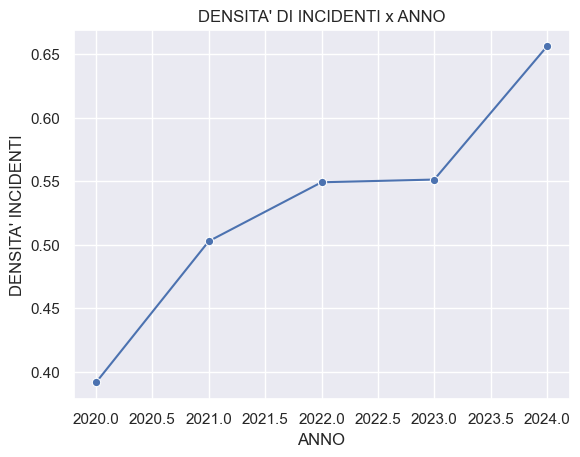

In [1726]:
sns.lineplot(data=densita_annua_nazionale,x="TIME_PERIOD",y="DENSITA_INCIDENTI",marker="o")

plt.title("DENSITA' DI INCIDENTI x ANNO")
plt.xlabel("ANNO")
plt.ylabel("DENSITA' INCIDENTI")
plt.show()

### CI SONO COMUNI CHE HANNO AVUTO ANDAMENTO MOLTO DIVERSO NEGLI ANNI TRA I PRIMI RECORD?

Tendenzialmente per numero di incidenti assoluti sono al primo posto sempre Roma e Milano per tutti gli anni presi in considerazione (aa 2020->2024)

In [1727]:
df_incidenti_annuali.groupby(["TIME_PERIOD", "COMUNE"])["OBS_VALUE"].sum().sort_values(ascending=False).head(20)

TIME_PERIOD  COMUNE 
2024         Roma       13924
2022         Roma       13181
2023         Roma       12817
2021         Roma       11129
2020         Roma        8229
2023         Milano      7812
2022         Milano      7783
2024         Milano      7743
2021         Milano      7465
2020         Milano      4856
2022         Genova      3910
2024         Genova      3872
2023         Genova      3669
2021         Genova      3584
2024         Torino      2968
2022         Torino      2935
2023         Torino      2918
2020         Genova      2840
2021         Torino      2793
2022         Firenze     2627
Name: OBS_VALUE, dtype: int64

# ANALISI TERRITORIALE_INFORMAZIONI COMUNI NEGLI ULTIMI 4 ANNI AGGREGATI

Per descrivere a livello comunale, i valori aggregati registrati di incidenti negli ultimi 4 anni.

In [1728]:
df_comuni_incidenti_total=pd.read_csv("df_clean/df_comuni_incidenti_total.csv")
df_comuni_incidenti_total.head()

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000)
0,1001,Agliè,14,2545,13.1462,193.592065,1.064947,5.500982
1,1002,Airasca,30,3633,15.7393,230.823480,1.906057,8.257638
2,1003,Ala di Stura,2,459,46.3315,9.906867,0.043167,4.357298
3,1004,Albiano d'Ivrea,15,1638,11.7314,139.625279,1.278620,9.157509
4,1006,Almese,21,6355,17.8756,355.512542,1.174786,3.304485


Creo le colonne per la classificazione dei comuni in base alla superficie e alla demografia secondo la classificazione ufficiale:

-Classificazione Comuni per superficie -> https://www.istat.it/it/files/2015/04/Superfici-delle-unit%C3%A0-amministrative-Testo-integrale.pdf

-Classificazione comuni per classe demografica (da comprimere) ->https://finanzalocale.interno.gov.it/docum/studi/varie/200707varclass.html#due

In [1729]:
df_comuni_incidenti_total["CLASSE_DEMOGRAFICA"] = ""

for i in df_comuni_incidenti_total.index:

    residenti = df_comuni_incidenti_total.loc[i, "RESIDENTI"]

    if residenti < 1000:
        df_comuni_incidenti_total.loc[i, "CLASSE_DEMOGRAFICA"] = "Molto piccolo"
    elif residenti < 5000:
        df_comuni_incidenti_total.loc[i, "CLASSE_DEMOGRAFICA"] = "Piccolo"
    elif residenti < 20000:
        df_comuni_incidenti_total.loc[i, "CLASSE_DEMOGRAFICA"] = "Medio"

    else:
        df_comuni_incidenti_total.loc[i, "CLASSE_DEMOGRAFICA"] = "Grande"

In [1730]:
df_comuni_incidenti_total["CLASSE_SUPERFICIE"] = ""

for i in df_comuni_incidenti_total.index:

    superficie = df_comuni_incidenti_total.loc[i, "SUPERFICIE (KMQ)"]

    if superficie < 10:
        df_comuni_incidenti_total.loc[i, "CLASSE_SUPERFICIE"] = "Molto piccolo"
    elif superficie < 50:
        df_comuni_incidenti_total.loc[i, "CLASSE_SUPERFICIE"] = "Piccolo"
    elif superficie < 100:
        df_comuni_incidenti_total.loc[i, "CLASSE_SUPERFICIE"] = "Medio"
    elif superficie < 250:
        df_comuni_incidenti_total.loc[i, "CLASSE_SUPERFICIE"] = "Grande"

    else:
        df_comuni_incidenti_total.loc[i, "CLASSE_SUPERFICIE"] = "Molto grande"

In [1731]:
df_comuni_incidenti_total.to_csv("df_clean/df_comuni_incidenti_aa20_24_classi.csv")

In [1732]:
print(df_comuni_incidenti_total["CLASSE_DEMOGRAFICA"].value_counts())
print("--------------------------------------")
print(df_comuni_incidenti_total["CLASSE_SUPERFICIE"].value_counts())

CLASSE_DEMOGRAFICA
Piccolo          3536
Molto piccolo    1996
Medio            1861
Grande            510
Name: count, dtype: int64
--------------------------------------
CLASSE_SUPERFICIE
Piccolo          4573
Molto piccolo    1641
Medio            1088
Grande            531
Molto grande       70
Name: count, dtype: int64


In [1733]:
df_comuni_incidenti_total

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000),CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
0,1001,Agliè,14,2545,13.1462,193.592065,1.064947,5.500982,Piccolo,Piccolo
1,1002,Airasca,30,3633,15.7393,230.823480,1.906057,8.257638,Piccolo,Piccolo
2,1003,Ala di Stura,2,459,46.3315,9.906867,0.043167,4.357298,Molto piccolo,Piccolo
3,1004,Albiano d'Ivrea,15,1638,11.7314,139.625279,1.278620,9.157509,Piccolo,Piccolo
4,1006,Almese,21,6355,17.8756,355.512542,1.174786,3.304485,Medio,Piccolo
...,...,...,...,...,...,...,...,...,...,...
7898,111103,Villaputzu,27,4497,181.3074,24.803180,0.148918,6.004003,Piccolo,Grande
7899,111104,Villasalto,9,999,130.3596,7.663417,0.069040,9.009009,Molto piccolo,Grande
7900,111105,Villasimius,39,3688,57.9708,63.618235,0.672752,10.574837,Piccolo,Medio
7901,111106,Villasor,57,6636,86.7935,76.457338,0.656731,8.589512,Medio,Medio


### COMUNI CON MAGGIOR NUMERO DI INCIDENTI NEGLI ULTIMI 4 ANNI?

Prendendo in considerazione il valore assoluto degli incidenti per comune, ne risulta al primo posto Roma come comune con più alto numero di incidenti negli ultimi 4 anni, seguita da Milano, Genova, Torino, Napoli.

Sono tutte metropoli in cui il valore alto dei residenti (in aggiunta i possibili turisti, lavoratori ecc. ) influisce sul traffico e la viabilità.

In [1734]:
df_comuni_incidenti_total.sort_values(by="OBS_VALUE", ascending=False).head(10)

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000),CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
4729,58091,Roma,59280,2770226,1287.3716,2151.846444,46.047311,21.398976,Grande,Molto grande
1775,15146,Milano,35659,1374582,181.6783,7566.021919,196.275505,25.941704,Grande,Grande
1266,10025,Genova,17875,566410,240.2876,2357.216935,74.390023,31.558412,Grande,Grande
267,1272,Torino,13702,858205,130.0645,6598.303150,105.347731,15.965882,Grande,Grande
5114,63049,Napoli,11219,922094,118.9441,7752.330717,94.321618,12.166872,Grande,Grande
4230,48017,Firenze,11019,368419,102.3156,3600.809652,107.696187,29.908881,Grande,Grande
3841,37006,Bologna,9461,391686,140.8566,2780.742968,67.167602,24.154552,Grande,Grande
6604,82053,Palermo,8633,637885,160.5878,3972.188423,53.758754,13.533787,Grande,Grande
5888,72006,Bari,7384,317205,117.4097,2701.693301,62.890886,23.278322,Grande,Grande
6841,87015,Catania,6333,300356,182.7960,1643.121294,34.645178,21.084979,Grande,Grande


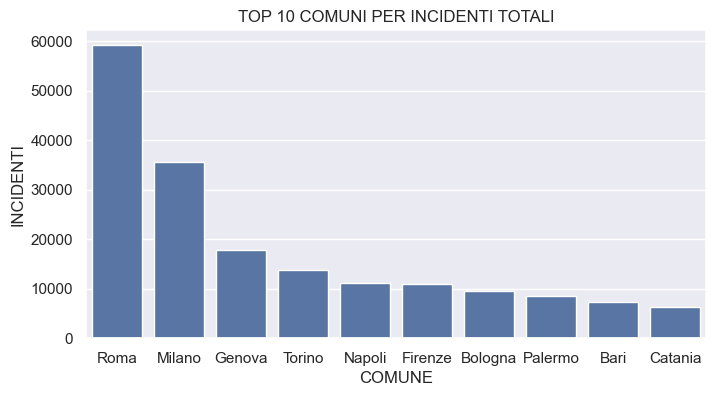

In [1735]:
plt.figure(figsize=(8, 4))

sns.barplot(data=df_comuni_incidenti_total.sort_values(by="OBS_VALUE", ascending=False).head(10), x="COMUNE", y="OBS_VALUE")
plt.ylabel("INCIDENTI")
plt.xlabel("COMUNE")
plt.title ("TOP 10 COMUNI PER INCIDENTI TOTALI")
plt.show()

### COMUNI CON MAGGIOR NUMERO DI INCIDENTI PRO CAPITE NEGLI ULTIMI 4 ANNI?

Prendendo in considerazione il valore degli incidenti pro capite per comune, viene inserito al primo posto Moncenisio come comune con più alto numero di incidenti pro capite negli ultimi 4 anni, seguita da Argentera, Rocca Pia, Brienno, Ponte Gardena/Waidbruck.

Sono tutti comuni molto piccoli, il valore pro capite è instabile per questi comuni poichè (Incidenti/Residenti) x 1000 ha come risultato valori alti quando ci sono pochi residenti.

Es. Moncenisio -->  (6/41) x 1000= 0,146 x 1000 = 146 (circa)

In [1736]:
df_comuni_incidenti_total.sort_values(by="INCIDENTI_PRO_CAPITE(1000)", ascending=False).head()
#avevo visto anche nell' EDA che qui torreggiavano i micro comuni

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000),CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
153,1157,Moncenisio,6,41,4.5007,9.109694,1.333126,146.341463,Molto piccolo,Molto piccolo
486,4006,Argentera,6,78,76.2591,1.022829,0.078679,76.923077,Molto piccolo,Medio
5516,66083,Rocca Pia,13,181,44.9610,4.025711,0.289139,71.823204,Molto piccolo,Piccolo
1498,13030,Brienno,24,335,8.9720,37.338386,2.674989,71.641791,Molto piccolo,Molto piccolo
2712,21065,Ponte Gardena/Waidbruck,14,201,2.3282,86.332789,6.013229,69.651741,Molto piccolo,Molto piccolo


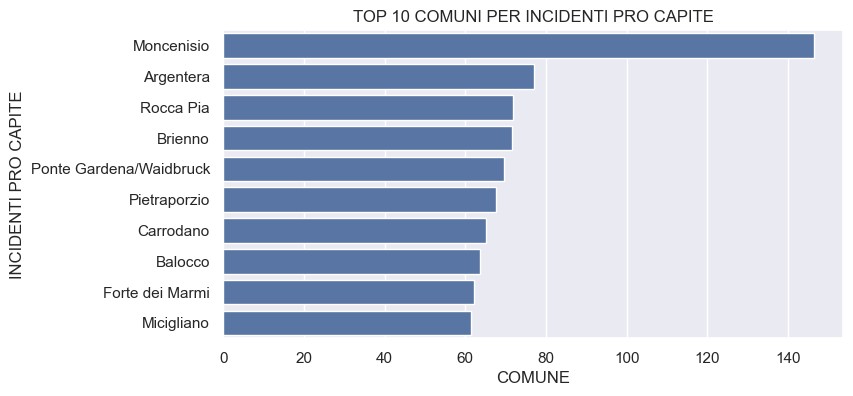

In [1737]:
plt.figure(figsize=(8, 4))

sns.barplot(data=df_comuni_incidenti_total.sort_values(by="INCIDENTI_PRO_CAPITE(1000)", ascending=False).head(10), x="INCIDENTI_PRO_CAPITE(1000)", y="COMUNE",
            orient="h")
plt.ylabel("INCIDENTI PRO CAPITE")
plt.xlabel("COMUNE")
plt.title ("TOP 10 COMUNI PER INCIDENTI PRO CAPITE")
plt.show()

### COMUNI CON MAGGIOR NUMERO DI DENSITA' DI INCIDENTI NEGLI ULTIMI 4 ANNI?

Prendendo in considerazione il valore assoluto degli incidenti per comune, ho stilato una classifica che vede al primo posto Milano come comune con registrati i più alti numeri di incidenti negli ultimi 4 anni, seguita da Cinisello Balsamo, Firenze, Torino, Bergamo.

In [1738]:
df_comuni_incidenti_total.sort_values(by="DENSITA_INCIDENTI", ascending=False).head(10)

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000),CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
1775,15146,Milano,35659,1374582,181.6783,7566.021919,196.275505,25.941704,Grande,Grande
1741,15077,Cinisello Balsamo,1392,74636,12.7241,5865.719383,109.398700,18.650517,Grande,Piccolo
4230,48017,Firenze,11019,368419,102.3156,3600.809652,107.696187,29.908881,Grande,Grande
267,1272,Torino,13702,858205,130.0645,6598.303150,105.347731,15.965882,Grande,Grande
1860,16024,Bergamo,4182,119993,40.1515,2988.506033,104.155511,34.852033,Grande,Piccolo
1748,15093,Corsico,553,34601,5.3556,6460.714019,103.256405,15.982197,Grande,Molto piccolo
1746,15086,Cormano,432,20317,4.4734,4541.735593,96.570841,21.262982,Grande,Molto piccolo
5114,63049,Napoli,11219,922094,118.9441,7752.330717,94.321618,12.166872,Grande,Grande
1815,15209,Sesto San Giovanni,1018,80203,11.6992,6855.426012,87.014497,12.692792,Grande,Piccolo
5124,63059,Portici,371,52721,4.6013,11457.848869,80.629387,7.037044,Grande,Molto piccolo


# ANALISI INCIDENTI per CLASSI DEMOGRAFICHE

In [1739]:
analisi_demografica = (df_comuni_incidenti_total.groupby("CLASSE_DEMOGRAFICA").agg(NUMERO_COMUNI=("ID_COMUNE", "count"),
                                                                                   RESIDENTI_MEDI=("RESIDENTI", "mean"),
                                                                                   INCIDENTI_TOTALI=("OBS_VALUE", "sum"),
                                                                                   INCIDENTI_MEDI=("OBS_VALUE", "mean"),
                                                                                   INCIDENTI_MEDIANA=("OBS_VALUE", "median"),
                                                                                   INCIDENTI_PRO_CAPITE_MEDI=("INCIDENTI_PRO_CAPITE(1000)", "mean"),
                                                                                   DENSITA_INCIDENTI_MEDIA=("DENSITA_INCIDENTI", "mean")).round(2))

analisi_demografica

,NUMERO_COMUNI,RESIDENTI_MEDI,INCIDENTI_TOTALI,INCIDENTI_MEDI,INCIDENTI_MEDIANA,INCIDENTI_PRO_CAPITE_MEDI,DENSITA_INCIDENTI_MEDIA
CLASSE_DEMOGRAFICA,,,,,,,
Grande,510,61925.41,525965,1031.30,433.5,13.59,15.84
Medio,1861,9596.77,176330,94.75,74.0,9.52,5.01
Molto piccolo,1996,541.70,7694,3.85,2.0,7.48,0.34
Piccolo,3536,2464.20,65879,18.63,14.0,7.43,1.31


In [1740]:
ordine=["Molto piccolo","Piccolo","Medio","Grande"]

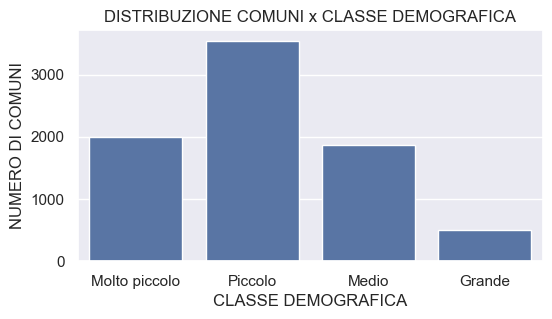

In [1741]:

plt.figure(figsize=(6,3))

sns.countplot(data=df_comuni_incidenti_total,x="CLASSE_DEMOGRAFICA",order=ordine)

plt.title("DISTRIBUZIONE COMUNI x CLASSE DEMOGRAFICA")
plt.xlabel("CLASSE DEMOGRAFICA")
plt.ylabel("NUMERO DI COMUNI")

plt.show()

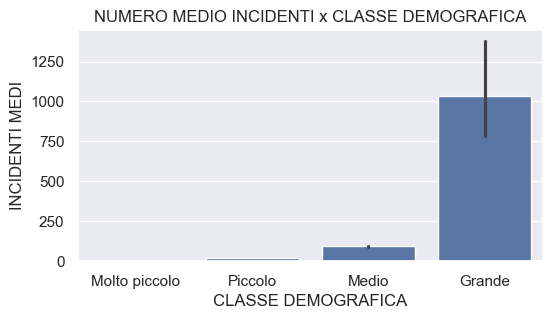

In [1742]:
plt.figure(figsize=(6,3))

sns.barplot(data=df_comuni_incidenti_total,x="CLASSE_DEMOGRAFICA",y="OBS_VALUE", order=ordine,estimator = "mean")

plt.title("NUMERO MEDIO INCIDENTI x CLASSE DEMOGRAFICA")
plt.xlabel("CLASSE DEMOGRAFICA")
plt.ylabel("INCIDENTI MEDI")

plt.show()

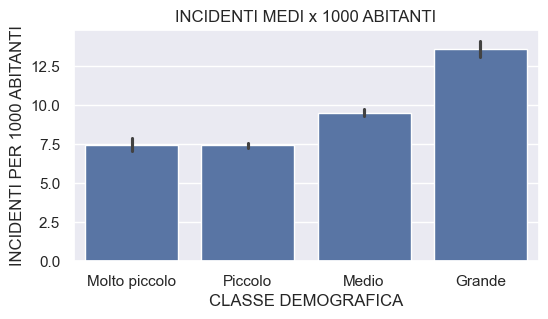

In [1743]:
plt.figure(figsize=(6,3))

sns.barplot(data=df_comuni_incidenti_total,x="CLASSE_DEMOGRAFICA",y="INCIDENTI_PRO_CAPITE(1000)", order=ordine, estimator = "mean")

plt.title("INCIDENTI MEDI x 1000 ABITANTI")
plt.xlabel("CLASSE DEMOGRAFICA")
plt.ylabel("INCIDENTI PER 1000 ABITANTI")

plt.show()

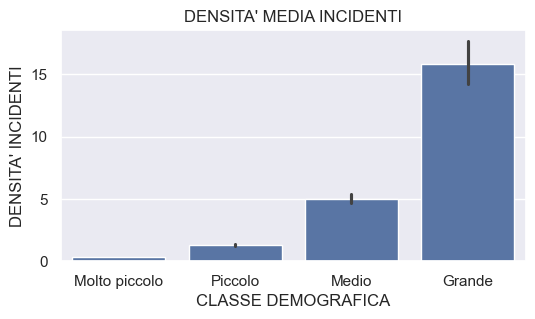

In [1744]:
plt.figure(figsize=(6,3))

sns.barplot(data=df_comuni_incidenti_total,x="CLASSE_DEMOGRAFICA",y="DENSITA_INCIDENTI",order=ordine, estimator = "mean")

plt.title("DENSITA' MEDIA INCIDENTI")
plt.xlabel("CLASSE DEMOGRAFICA")
plt.ylabel("DENSITA' INCIDENTI")

plt.show()

In [1745]:
df_comuni_incidenti_total.groupby("CLASSE_DEMOGRAFICA")[["OBS_VALUE",
                                                         "INCIDENTI_PRO_CAPITE(1000)",
                                                         "DENSITA_INCIDENTI"]].median()

,OBS_VALUE,INCIDENTI_PRO_CAPITE(1000),DENSITA_INCIDENTI
CLASSE_DEMOGRAFICA,,,
Grande,433.5,12.777469,8.707401
Medio,74.0,8.869610,2.730328
Molto piccolo,2.0,4.821214,0.134211
Piccolo,14.0,6.303545,0.592219


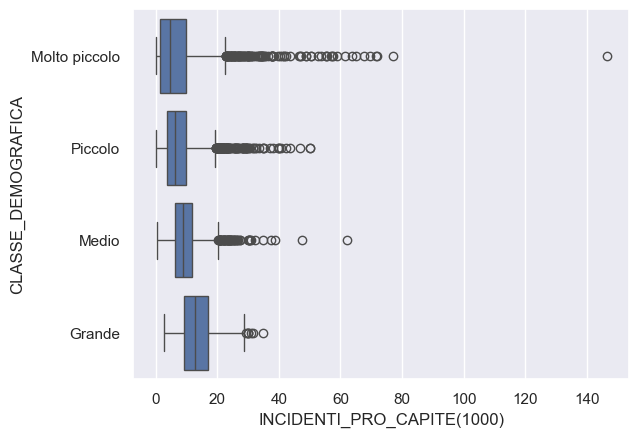

In [1746]:
sns.boxplot(data=df_comuni_incidenti_total,x="INCIDENTI_PRO_CAPITE(1000)", y="CLASSE_DEMOGRAFICA", order=ordine)

plt.show()

#La mediana (linea centrale) aumenta davvero, concorde con l'aumentare degli incidenti pro capite e la media
# I comuni molto piccoli presentano il maggior numero di outlier, ma la loro mediana è la più bassa tra le classi demografiche.
# Questo suggerisce che i valori estremi osservati durante l'EDA sono dovuti a pochi comuni eccezionali e non rappresentano
# il comportamento generale della classe.

# ANALISI INCIDENTI per CLASSI SUPERFICIE

In [1747]:
analisi_superficie = (df_comuni_incidenti_total.groupby("CLASSE_SUPERFICIE").agg(NUMERO_COMUNI=("ID_COMUNE", "count"),
                                                                                 SUPERFICIE_MEDIA=("SUPERFICIE (KMQ)", "mean"),
                                                                                 INCIDENTI_TOTALI=("OBS_VALUE", "sum"),
                                                                                 INCIDENTI_MEDI=("OBS_VALUE", "mean"),
                                                                                 INCIDENTI_MEDIANA=("OBS_VALUE", "median"),
                                                                                 INCIDENTI_PRO_CAPITE_MEDI=("INCIDENTI_PRO_CAPITE(1000)", "mean"),
                                                                                 DENSITA_INCIDENTI_MEDIA=("DENSITA_INCIDENTI", "mean")).round(2))

analisi_superficie

,NUMERO_COMUNI,SUPERFICIE_MEDIA,INCIDENTI_TOTALI,INCIDENTI_MEDI,INCIDENTI_MEDIANA,INCIDENTI_PRO_CAPITE_MEDI,DENSITA_INCIDENTI_MEDIA
CLASSE_SUPERFICIE,,,,,,,
Grande,531,148.07,256698,483.42,56.0,10.28,3.15
Medio,1088,69.77,128987,118.55,25.0,8.77,1.72
Molto grande,70,361.09,107453,1535.04,351.0,12.08,2.49
Molto piccolo,1641,6.20,46899,28.58,10.0,7.69,5.22
Piccolo,4573,24.51,235831,51.57,14.0,8.18,2.28


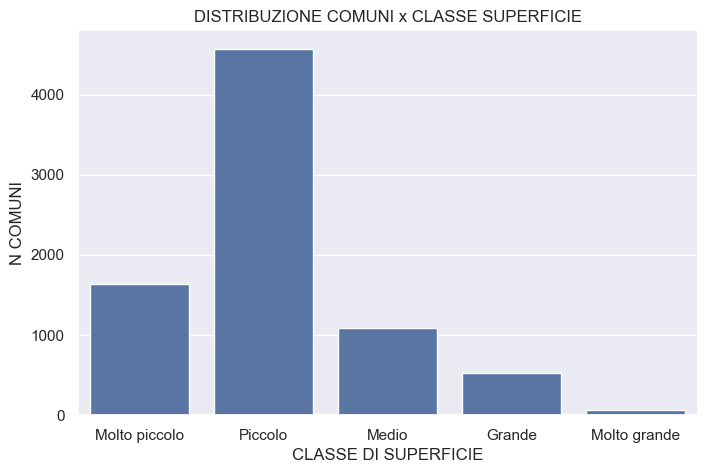

In [1748]:
ordine = ["Molto piccolo","Piccolo","Medio","Grande","Molto grande"]

plt.figure(figsize=(8,5))
sns.countplot(data=df_comuni_incidenti_total,x="CLASSE_SUPERFICIE",order=ordine)

plt.title("DISTRIBUZIONE COMUNI x CLASSE SUPERFICIE")
plt.xlabel("CLASSE DI SUPERFICIE")
plt.ylabel("N COMUNI")

plt.show()

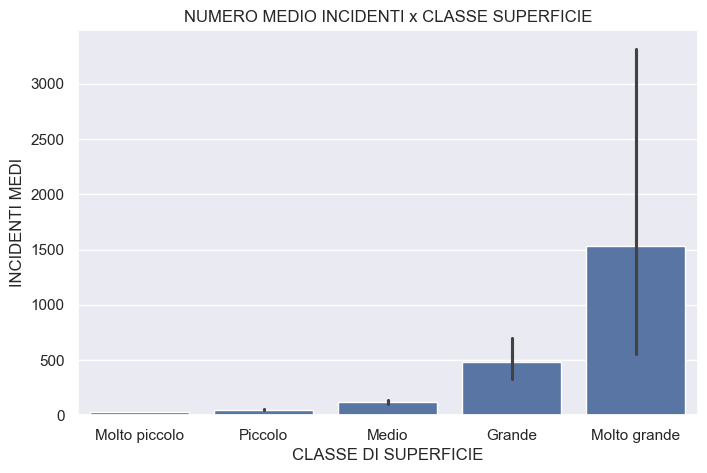

In [1749]:
plt.figure(figsize=(8,5))

sns.barplot(data=df_comuni_incidenti_total,x="CLASSE_SUPERFICIE", y="OBS_VALUE",order=ordine, estimator = "mean")

plt.title("NUMERO MEDIO INCIDENTI x CLASSE SUPERFICIE")
plt.xlabel("CLASSE DI SUPERFICIE")
plt.ylabel("INCIDENTI MEDI")

plt.show()

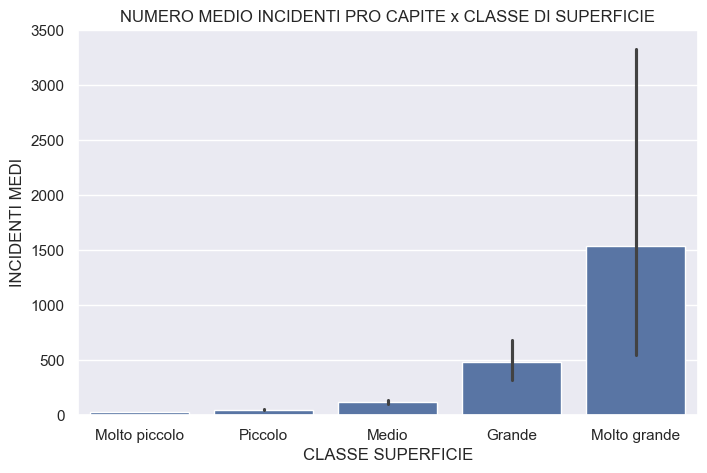

In [1750]:
plt.figure(figsize=(8,5))

sns.barplot(data=df_comuni_incidenti_total,x="CLASSE_SUPERFICIE",y="OBS_VALUE",order=ordine, estimator = "mean")

plt.title("NUMERO MEDIO INCIDENTI PRO CAPITE x CLASSE DI SUPERFICIE")
plt.xlabel("CLASSE SUPERFICIE")
plt.ylabel("INCIDENTI MEDI")

plt.show()

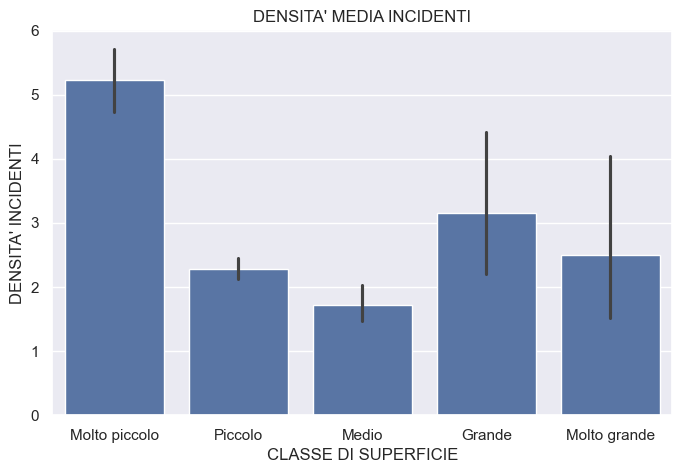

In [1751]:
plt.figure(figsize=(8,5))

sns.barplot(data=df_comuni_incidenti_total,x="CLASSE_SUPERFICIE",y="DENSITA_INCIDENTI",order=ordine, estimator = "mean")

plt.title("DENSITA' MEDIA INCIDENTI")
plt.xlabel("CLASSE DI SUPERFICIE")
plt.ylabel("DENSITA' INCIDENTI")

plt.show()

In [1752]:
df_comuni_incidenti_total.groupby("CLASSE_SUPERFICIE")[["OBS_VALUE","INCIDENTI_PRO_CAPITE(1000)",
                                                        "DENSITA_INCIDENTI"]].median().round(2)

,OBS_VALUE,INCIDENTI_PRO_CAPITE(1000),DENSITA_INCIDENTI
CLASSE_SUPERFICIE,,,
Grande,56.0,9.31,0.36
Medio,25.0,7.81,0.36
Molto grande,351.0,11.68,0.95
Molto piccolo,10.0,5.93,1.74
Piccolo,14.0,7.06,0.67


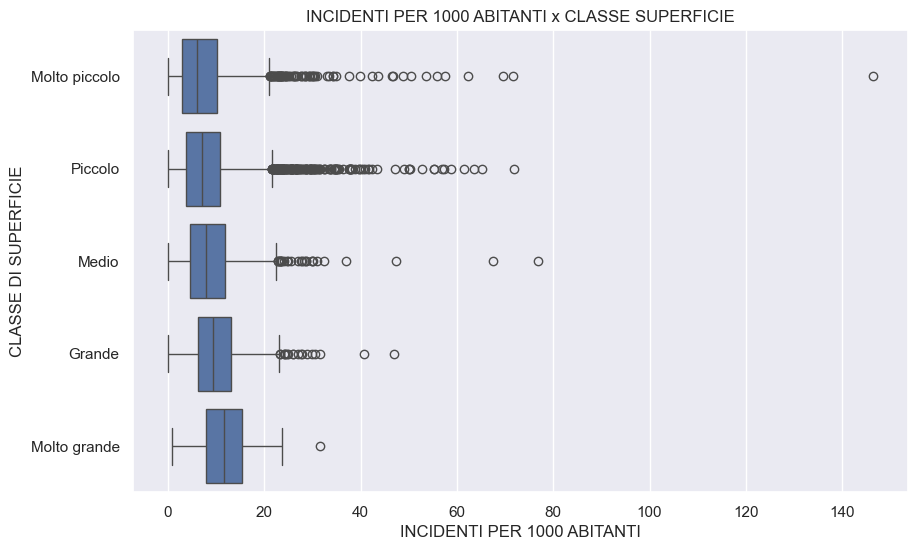

In [1753]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_comuni_incidenti_total,x="INCIDENTI_PRO_CAPITE(1000)",y="CLASSE_SUPERFICIE",
            order=ordine)

plt.title("INCIDENTI PER 1000 ABITANTI x CLASSE SUPERFICIE")
plt.xlabel("INCIDENTI PER 1000 ABITANTI")
plt.ylabel("CLASSE DI SUPERFICIE")

plt.show()

Confronto tra le due analisi a livello di classi.
------------------------
Classe demografica:

Le mediane aumentano passando da "Molto piccolo" a "Grande"

I micro-comuni concentravano la maggior parte degli outlier

La dimensione della popolazione sembrava influenzare il tasso di incidentalità

----------------------------
Classe di superficie:

Le mediane sono abbastanza vicine

Il box è molto simile tra le classi

Gli outlier sono distribuiti in tutte le classi

Non si osserva un trend crescente evidente come nel caso della popolazione

Quindi, descrittivamente, la superficie sembra avere un'influenza molto più debole, non rappresentando 

un fattore determinante nella spiegazione del livello di incidentalità

# TEST
Per capire se i comportamenti delle classi demografiche differiscono tra di loro rispetto agli incidenti pro capite

In [1754]:
import scipy.stats as stats

In [1755]:
df_comuni_incidenti_total[["INCIDENTI_PRO_CAPITE(1000)","RESIDENTI",
                   "SUPERFICIE (KMQ)", "OBS_VALUE", "DENSITA_POPOLAZIONE",
                     "DENSITA_INCIDENTI"]].corr()

,INCIDENTI_PRO_CAPITE(1000),RESIDENTI,SUPERFICIE (KMQ),OBS_VALUE,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI
INCIDENTI_PRO_CAPITE(1000),1.000000,0.122196,0.106583,0.135570,0.085535,0.290062
RESIDENTI,0.122196,1.000000,0.379852,0.976172,0.286153,0.445362
SUPERFICIE (KMQ),0.106583,0.379852,1.000000,0.347678,-0.121676,-0.030898
OBS_VALUE,0.135570,0.976172,0.347678,1.000000,0.229590,0.432826
DENSITA_POPOLAZIONE,0.085535,0.286153,-0.121676,0.229590,1.000000,0.811091
DENSITA_INCIDENTI,0.290062,0.445362,-0.030898,0.432826,0.811091,1.000000


## ANOVA (analisi della varianza)

Vorrei capire se le città grandi o piccole (in base alla classe demografica) abbiano comportamenti differenti rispetto a incidenti pro capite utilizzando ANOVA

Ipotesi nulla (H0) = La media del tasso di incidenti per 1000 abitanti è uguale in tutte le classi demografiche.
Ipotesi alternativa (H1) = Almeno una classe demografica presenta una media diversa.

In [1756]:
molto_piccolo = df_comuni_incidenti_total[df_comuni_incidenti_total["CLASSE_DEMOGRAFICA"] == "Molto piccolo"]["INCIDENTI_PRO_CAPITE(1000)"]

piccolo = df_comuni_incidenti_total[df_comuni_incidenti_total["CLASSE_DEMOGRAFICA"] == "Piccolo"]["INCIDENTI_PRO_CAPITE(1000)"]

medio = df_comuni_incidenti_total[df_comuni_incidenti_total["CLASSE_DEMOGRAFICA"] == "Medio"]["INCIDENTI_PRO_CAPITE(1000)"]

grande = df_comuni_incidenti_total[df_comuni_incidenti_total["CLASSE_DEMOGRAFICA"] == "Grande"]["INCIDENTI_PRO_CAPITE(1000)"]

In [1757]:
#ANOVA
f = stats.f_oneway(molto_piccolo,piccolo,medio,grande)

print(f'F-statistic: {f.statistic}')
print(f'P-value [%]: {f.pvalue*100:.10f}')

alpha = 0.05

if f.pvalue <= alpha:
    print("p-value <= alpha | risultato statisticamente significativo | H0 rifiutata")
else:
    print("p-value > alpha | risultato non statisticamente significativo | non si rifiuta H0")

# F-statistic = 152.29 è molto alta: significa che la variabilità tra i gruppi è molto maggiore della variabilità dentro i gruppi.
# P-value [%] = 0.00.. indica che la probabilità di ottenere un risultato così estremo se l’ipotesi nulla fosse vera è trascurabile.
# Quindi H0 viene rifiutata: le medie non sono tutte uguali

F-statistic: 152.28777513104941
P-value [%]: 0.0000000000
p-value <= alpha | risultato statisticamente significativo | H0 rifiutata


In [1758]:
#T-TEST
# Dopo aver verificato con ANOVA l'esistenza di differenze
# tra le classi demografiche, confrontiamo direttamente
# i comuni grandi e molto piccoli tramite t-test.
t_stat, p_value = stats.ttest_ind(grande, molto_piccolo)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

alpha = 0.05

if p_value <= alpha:
    print("p-value <= alpha | risultato statisticamente significativo | H0 rifiutata")
else:
    print("p-value > alpha | risultato non statisticamente significativo | non si rifiuta H0")

T-statistic: 13.498090884234253
P-value: 3.924688406069511e-40
p-value <= alpha | risultato statisticamente significativo | H0 rifiutata


# REGRESSIONE LINEARE

Relazione tra densità abitativa e densità degli incidenti, quanto spiega (R-square)? 

Relazione tra residenti e incidenti assoluti, quanto spiega (R-square)? 





TRA LE DUE DENSITA'

In [1759]:
df_comuni_incidenti_total[["DENSITA_POPOLAZIONE", "DENSITA_INCIDENTI"]].corr()

,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI
DENSITA_POPOLAZIONE,1.000000,0.811091
DENSITA_INCIDENTI,0.811091,1.000000


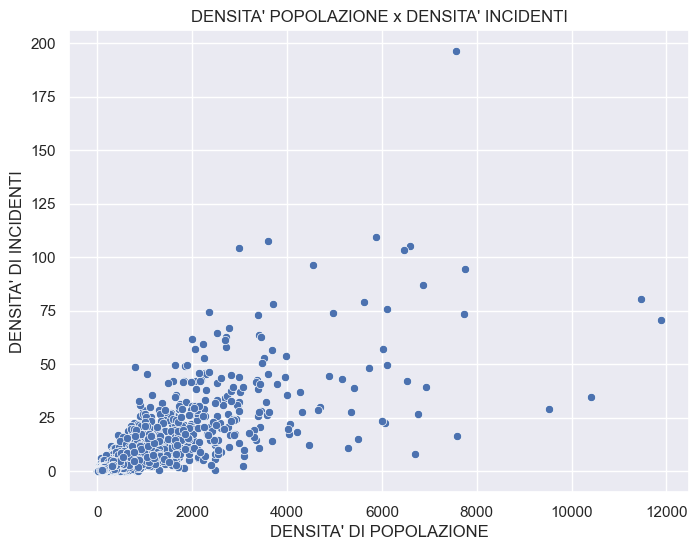

In [1760]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df_comuni_incidenti_total,x="DENSITA_POPOLAZIONE",y="DENSITA_INCIDENTI")

plt.title("DENSITA' POPOLAZIONE x DENSITA' INCIDENTI")
plt.xlabel("DENSITA' DI POPOLAZIONE")
plt.ylabel("DENSITA' DI INCIDENTI")

plt.show()

In [1761]:
import statsmodels.api as sm
X = df_comuni_incidenti_total["DENSITA_POPOLAZIONE"] #variabile indipendente-predittore
y = df_comuni_incidenti_total["DENSITA_INCIDENTI"] #variabile dipendente

X = sm.add_constant(X)

model1 = sm.OLS(y, X).fit()
print(model1.summary())

# Dal modello:
# R-squared = 0.658: la densità di popolazione spiega circa il 65.8% della variabilità della densità incidenti.
# Coefficiente di DENSITA_POPOLAZIONE = 0.0094: all’aumentare della densità di popolazione, aumenta anche la densità di incidenti. Un aumento di 1.000 abitanti/kmq è associato, in media, a un incremento di circa 9,4 incidenti/kmq.
# P>|t| = 0.000: il coefficiente è statisticamente significativo.
# Quindi la relazione è forte e positiva.

                            OLS Regression Results                            
Dep. Variable:      DENSITA_INCIDENTI   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                 1.519e+04
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:30:02   Log-Likelihood:                -22815.
No. Observations:                7903   AIC:                         4.563e+04
Df Residuals:                    7901   BIC:                         4.565e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0467    

In [1762]:
model1.params
# 0.046718 - intercetta
# 0.0094 - coefficiente angolare (slope)

const                  0.046718
DENSITA_POPOLAZIONE    0.009448
dtype: float64

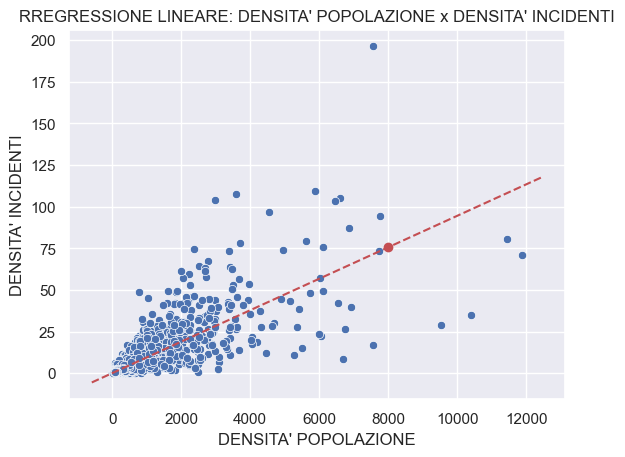

In [1763]:
#Grafico della retta di regressione

#Coefficienti della retta
intercept=model1.params["const"]
slope=model1.params["DENSITA_POPOLAZIONE"]

sns.scatterplot(x="DENSITA_POPOLAZIONE",y="DENSITA_INCIDENTI",
                data=df_comuni_incidenti_total)
plt.xlabel("DENSITA' POPOLAZIONE")
plt.ylabel("DENSITA' INCIDENTI")
plt.title("RREGRESSIONE LINEARE: DENSITA' POPOLAZIONE x DENSITA' INCIDENTI")


#Limiti asse X
axes = plt.gca()
x_vals = np.array(axes.get_xlim())

#Eq della retta
y_vals = intercept + slope * x_vals

#Plot della retta di regressione
plt.plot(x_vals, y_vals, "--", color="r")

#Plot della previsione per un comune con 8000 abitanti/kmq
plt.plot(8000, model1.predict(np.array([[1, 8000]]))[0], "ro")

plt.show()

Il punto rosso rappresenta la previsione del modello per un comune con una densità di popolazione pari a 8.000 abitanti/kmq

TRA OBS_VALUE E RESIDENTI

In [1764]:
df_comuni_incidenti_total[["RESIDENTI", "OBS_VALUE"]].corr()

df_comuni_incidenti_total[["INCIDENTI_PRO_CAPITE(1000)","RESIDENTI",
                   "SUPERFICIE (KMQ)", "OBS_VALUE", "DENSITA_POPOLAZIONE",
                     "DENSITA_INCIDENTI"]].corr()

,INCIDENTI_PRO_CAPITE(1000),RESIDENTI,SUPERFICIE (KMQ),OBS_VALUE,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI
INCIDENTI_PRO_CAPITE(1000),1.000000,0.122196,0.106583,0.135570,0.085535,0.290062
RESIDENTI,0.122196,1.000000,0.379852,0.976172,0.286153,0.445362
SUPERFICIE (KMQ),0.106583,0.379852,1.000000,0.347678,-0.121676,-0.030898
OBS_VALUE,0.135570,0.976172,0.347678,1.000000,0.229590,0.432826
DENSITA_POPOLAZIONE,0.085535,0.286153,-0.121676,0.229590,1.000000,0.811091
DENSITA_INCIDENTI,0.290062,0.445362,-0.030898,0.432826,0.811091,1.000000


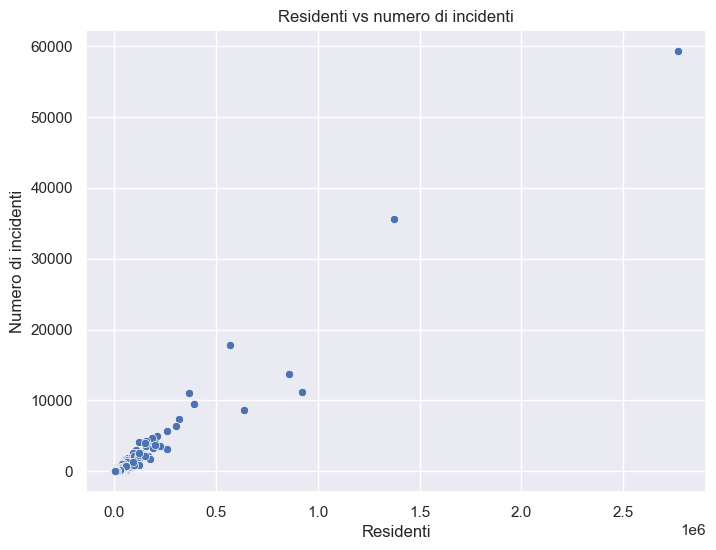

In [1765]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df_comuni_incidenti_total,x="RESIDENTI",y="OBS_VALUE")

plt.title("Residenti vs numero di incidenti")
plt.xlabel("Residenti")
plt.ylabel("Numero di incidenti")

plt.show()

In [1766]:
X = df_comuni_incidenti_total["RESIDENTI"]
y = df_comuni_incidenti_total["OBS_VALUE"]

X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()

print(model2.summary())

# Dal modello:
# R-squared = 0.953: la variabile "residenti" spiega circa il 95% della variabilità degli incidenti assoluti
# Coefficiente di RESIDENTI = 0.0208: all’aumentare dei residenti, aumentano anche gli incidenti. Ogni 100 residenti ci saranno circa 2 incidenti in più
# P>|t| = 0.000: il coefficiente è statisticamente significativo.
# Quindi la relazione è forte e positiva.

                            OLS Regression Results                            
Dep. Variable:              OBS_VALUE   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                 1.599e+05
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:30:02   Log-Likelihood:                -52832.
No. Observations:                7903   AIC:                         1.057e+05
Df Residuals:                    7901   BIC:                         1.057e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -57.7954      2.213    -26.113      0.0

In [1767]:
model2.params

const       -57.795393
RESIDENTI     0.020809
dtype: float64

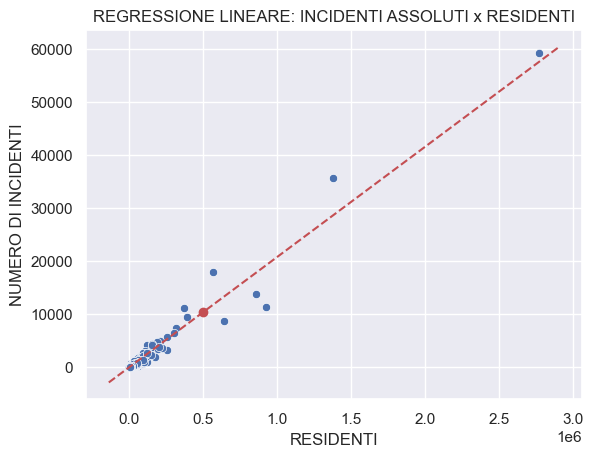

In [1768]:
intercept = model2.params["const"]
slope = model2.params["RESIDENTI"]

sns.scatterplot(data=df_comuni_incidenti_total,x="RESIDENTI",
                y="OBS_VALUE")
plt.xlabel("RESIDENTI")
plt.ylabel("NUMERO DI INCIDENTI")
plt.title("REGRESSIONE LINEARE: INCIDENTI ASSOLUTI x RESIDENTI")

axes = plt.gca()
x_vals = np.array(axes.get_xlim())


y_vals = intercept + slope * x_vals


plt.plot(x_vals, y_vals, "--", color="r")


plt.plot(500000,model2.predict(np.array([1, 500000]))[0],"ro")



plt.show()

# CLUSTERING

Utilizzare il K-Means per individuare gruppi omogenei di comuni in base al loro profilo, così da supportare il processo decisionale per la priorità di intervento in ambito di sicurezza stradale. 

Per trovare i comuni dove un investimento avrebbe il maggiore impatto, questo tiene in considerazione anche la differenza tra gli abitanti (problema micro comuni)

3 variabili:

RESIDENTI--> così da tener conto della popolazione (sistemando i micro comuni)

INCIDENTI PRO CAPITE --> così da tener conto degli incidenti normalizzati e non assoluti

DENSITA' INCIDENTI-->che tiene coto di quanti incidenti ci siano stati in base alla superficie

In [1769]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

df_comuni_incidenti_total[["INCIDENTI_PRO_CAPITE(1000)","DENSITA_INCIDENTI", "RESIDENTI"]].corr()

,INCIDENTI_PRO_CAPITE(1000),DENSITA_INCIDENTI,RESIDENTI
INCIDENTI_PRO_CAPITE(1000),1.000000,0.290062,0.122196
DENSITA_INCIDENTI,0.290062,1.000000,0.445362
RESIDENTI,0.122196,0.445362,1.000000


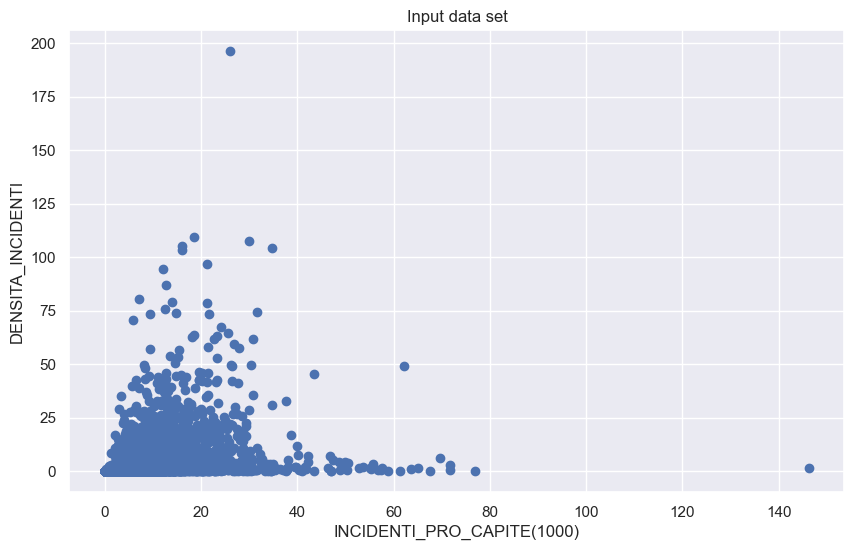

In [1770]:
# K-MEANS - SEGMENTAZIONE DEI COMUNI IN BASE AL RISCHIO
# Preparazione dei dati
input_dataframe = df_comuni_incidenti_total[["INCIDENTI_PRO_CAPITE(1000)","DENSITA_INCIDENTI", "RESIDENTI"]]

plt.figure(figsize=(10, 6))
plt.scatter(input_dataframe["INCIDENTI_PRO_CAPITE(1000)"], input_dataframe["DENSITA_INCIDENTI"], marker="o")
plt.title('Input data set')
plt.xlabel('INCIDENTI_PRO_CAPITE(1000)')
plt.ylabel('DENSITA_INCIDENTI')

plt.show()

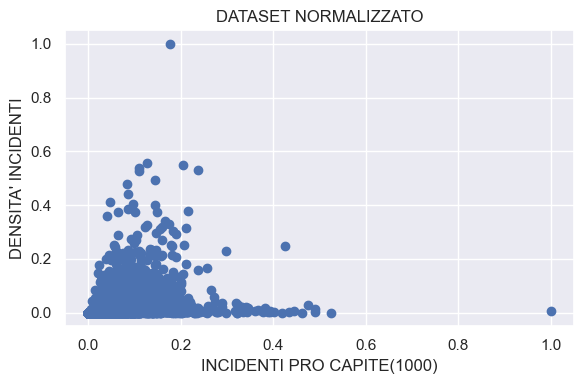

In [1781]:
scaler = MinMaxScaler()

scaled_dataframe = pd.DataFrame(scaler.fit_transform(input_dataframe),
                                columns=input_dataframe.columns)

# Visualizzazione del dataset normalizzato
plt.figure(figsize=(6, 4))

plt.scatter(scaled_dataframe["INCIDENTI_PRO_CAPITE(1000)"],
            scaled_dataframe["DENSITA_INCIDENTI"],
            marker="o")

plt.title("DATASET NORMALIZZATO")
plt.xlabel("INCIDENTI PRO CAPITE(1000)")
plt.ylabel("DENSITA' INCIDENTI")

plt.tight_layout()

plt.show()

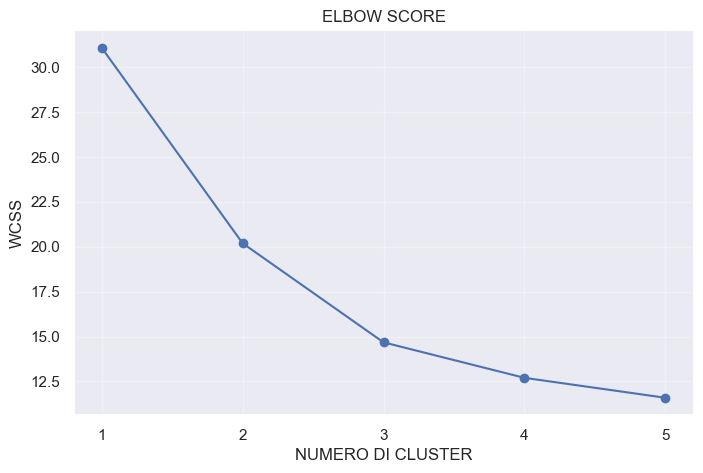

In [1783]:
# Metodo del gomito-Elbow score
k_values = range(1, 6)
wcss = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_dataframe)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, wcss,marker="o")
plt.title("ELBOW SCORE")
plt.xlabel("NUMERO DI CLUSTER")
plt.ylabel("WCSS")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

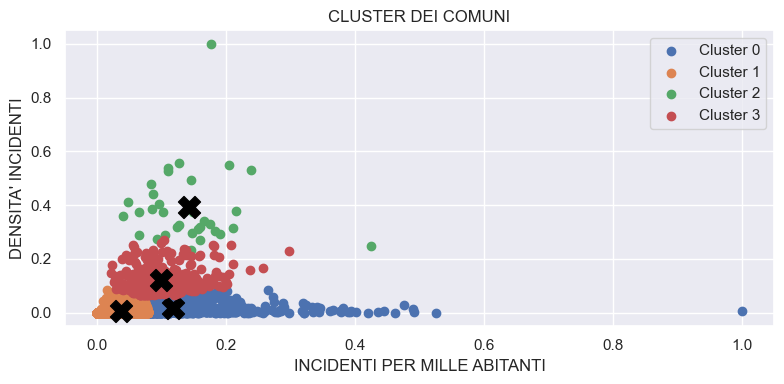

In [ ]:
# MODELLO K-MEANS

# Inizializzazione e addestramento del modello
kmeans = KMeans(n_clusters=4,random_state=42)
kmeans.fit(scaled_dataframe)

# Assegnazione dei cluster al DataFrame normalizzato
scaled_dataframe["CLUSTER"] = kmeans.labels_
# Copia dei cluster nel DataFrame originale
df_comuni_incidenti_total["CLUSTER"] = scaled_dataframe["CLUSTER"]


# VISUALIZZAZIONE DEI CLUSTER
centroids = kmeans.cluster_centers_
clusters = scaled_dataframe.groupby("CLUSTER")

plt.figure(figsize=(8,4))

for cluster, data in clusters:

    plt.scatter(data["INCIDENTI_PRO_CAPITE(1000)"],data["DENSITA_INCIDENTI"],
                label=f"Cluster {cluster}")

    plt.scatter(centroids[cluster, 0],centroids[cluster, 1],marker="X",color="black",
                s=250)

plt.xlabel("INCIDENTI PER MILLE ABITANTI")
plt.ylabel("DENSITA' INCIDENTI")
plt.title("CLUSTER DEI COMUNI")
plt.legend()

plt.tight_layout()

plt.show()

In [1774]:
profilo_cluster = (df_comuni_incidenti_total.groupby("CLUSTER")[["RESIDENTI","INCIDENTI_PRO_CAPITE(1000)",
                                                                 "DENSITA_INCIDENTI","OBS_VALUE",
                                                                 "DENSITA_POPOLAZIONE"]].mean().round(2))

profilo_cluster

,RESIDENTI,INCIDENTI_PRO_CAPITE(1000),DENSITA_INCIDENTI,OBS_VALUE,DENSITA_POPOLAZIONE
CLUSTER,,,,,
0,9284.37,17.27,3.16,147.74,204.66
1,4104.24,5.47,1.27,28.15,212.34
2,284456.68,20.90,77.00,6033.94,4554.18
3,32512.71,14.44,24.02,523.97,1996.46


In [1775]:
df_comuni_incidenti_total["CLUSTER"].value_counts()

CLUSTER
1    5921
0    1639
3     309
2      34
Name: count, dtype: int64

In [1776]:
#CLUSTER OMOGENEITA' PER IL NUMERO DI RESIDENTI, INCIDENTI PRO CAPITE E DENSITA', PIU' DENSITA' DI INCIDENTI NEL GRUPPO 2
df_comuni_incidenti_total[df_comuni_incidenti_total["CLUSTER"] == 2].sort_values(by="DENSITA_INCIDENTI",ascending=False).head(10)

,ID_COMUNE,COMUNE,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_INCIDENTI,INCIDENTI_PRO_CAPITE(1000),CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE,CLUSTER
1775,15146,Milano,35659,1374582,181.6783,7566.021919,196.275505,25.941704,Grande,Grande,2
1741,15077,Cinisello Balsamo,1392,74636,12.7241,5865.719383,109.398700,18.650517,Grande,Piccolo,2
4230,48017,Firenze,11019,368419,102.3156,3600.809652,107.696187,29.908881,Grande,Grande,2
267,1272,Torino,13702,858205,130.0645,6598.303150,105.347731,15.965882,Grande,Grande,2
1860,16024,Bergamo,4182,119993,40.1515,2988.506033,104.155511,34.852033,Grande,Piccolo,2
1748,15093,Corsico,553,34601,5.3556,6460.714019,103.256405,15.982197,Grande,Molto piccolo,2
1746,15086,Cormano,432,20317,4.4734,4541.735593,96.570841,21.262982,Grande,Molto piccolo,2
5114,63049,Napoli,11219,922094,118.9441,7752.330717,94.321618,12.166872,Grande,Grande,2
1815,15209,Sesto San Giovanni,1018,80203,11.6992,6855.426012,87.014497,12.692792,Grande,Piccolo,2
5124,63059,Portici,371,52721,4.6013,11457.848869,80.629387,7.037044,Grande,Molto piccolo,2


Questi sono comuni ad elevata mobilità e densità di popolazione, quindi potrebbero essere soggetti a più incidenti, infatti sono comuni con forte esposizione al traffico (infatti vedi Milano e limitrofi)

In [1777]:
os.listdir("df_clean")

['df_comuni_incidenti_aa20_24_classi.csv',
 'df_comuni_incidenti_total.csv',
 'df_final_from_20_to_24_clean.csv',
 'df_incidenti.csv',
 'df_istat_clean.csv',
 'df_situas_clean.csv',
 'final_df_comuni_incidenti_20t24.csv']

In [1778]:
df_cluster2=df_comuni_incidenti_total[df_comuni_incidenti_total["CLUSTER"] == 2].sort_values(by="DENSITA_INCIDENTI",ascending=False)

df_cluster2.count()

ID_COMUNE                     34
COMUNE                        34
OBS_VALUE                     34
RESIDENTI                     34
SUPERFICIE (KMQ)              34
DENSITA_POPOLAZIONE           34
DENSITA_INCIDENTI             34
INCIDENTI_PRO_CAPITE(1000)    34
CLASSE_DEMOGRAFICA            34
CLASSE_SUPERFICIE             34
CLUSTER                       34
dtype: int64

In [1779]:
df_provincia = pd.read_csv ("df_clean/df_final_from_20_to_24_clean.csv")
df_provincia = df_comuni_incidenti_total.merge(df_provincia[["ID_COMUNE","CODICE PROVINCIA"]], on="ID_COMUNE", how="left")

df_provincia_milano=df_provincia[df_provincia["CODICE PROVINCIA"]==215].sort_values(by="DENSITA_INCIDENTI", ascending=False)
#voglio vedere i comuni connessi alla provincia di Milano e che presentano dunque alta densità di incidenti
#così da vedere se l' alta urbanizzazione aumenti il rischio di incidenti
df_comuni_prov_di_milano=df_provincia_milano.groupby("COMUNE")[[ "RESIDENTI", "INCIDENTI_PRO_CAPITE(1000)", "DENSITA_INCIDENTI", "OBS_VALUE", "DENSITA_POPOLAZIONE"]].mean().sort_values(by="DENSITA_INCIDENTI", ascending=False)
df_comuni_prov_di_milano

df_cluster_milano = df_cluster2[df_cluster2["ID_COMUNE"].isin(df_provincia_milano["ID_COMUNE"])]


print("I comuni presenti nel cluster 2, in provincia di Milano sono:",df_cluster_milano["ID_COMUNE"].nunique())

I comuni presenti nel cluster 2, in provincia di Milano sono: 12


L’analisi del cluster 2 è stata estesa al livello provinciale per verificare se il rischio risulti territorialmente concentrato. La presenza di più comuni della stessa provincia nello stesso cluster ad alto rischio può indicare un’area critica, suggerendo di orientare gli investimenti anche verso i comuni limitrofi.


In [1780]:
final_df_comuni_incidenti_20t24= df_comuni_incidenti_total
final_df_comuni_incidenti_20t24.to_csv("df_clean/final_df_comuni_incidenti_20t24.csv")

# CONCLUSIONI

Gli incidenti risultano concentrati nei grandi centri urbani e nelle aree ad elevata mobilità.

La densità abitativa mostra una relazione positiva con la densità degli incidenti. Mentre non vi sono relazioni tra densità abitativa e incidenti pro capite, dunque un comune popoloso non è segno necessariamente di un rischio maggiore di incidenti ogni 1000 abitanti.

Il clustering ha individuato quattro profili territoriali distinti. Uno dei cluster (2) è costituito principalmente da grandi aree metropolitane e comuni limitrofi.
Circa un terzo dei comuni appartenenti al cluster più critico ricade nella provincia di Milano, suggerendo che quest'area possa rappresentare una priorità per eventuali interventi coordinati di sicurezza stradale.